In [1]:
!pip install scipy matplotlib

In [ ]:
from ib_insync import *
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

util.startLoop()

spots = pd.read_parquet('../data/raw/spots_2026-06-11.parquet', engine='fastparquet')
opts = pd.read_parquet('../data/raw/options_AAPL_2026-06-11.parquet', engine='fastparquet')

spot_aapl = spots[spots['symbol'] == 'AAPL']['last'].values[0]
print(f"AAPL spot: {spot_aapl}")
print(f"Options: {len(opts)} contrats")

AAPL spot: 290.18
Options: 134 contrats


In [3]:
# === STEP 5: Mid-price pour chaque option ===

opts['mid'] = (opts['bid'] + opts['ask']) / 2
opts = opts.dropna(subset=['bid', 'ask'])  # virer les options sans quote

# Séparer calls et puts
calls = opts[opts['right'] == 'C'].copy()
puts = opts[opts['right'] == 'P'].copy()

print(f"Calls avec quote: {len(calls)}")
print(f"Puts avec quote: {len(puts)}")
calls[['expiry', 'strike', 'bid', 'ask', 'mid']].head(10)

Calls avec quote: 61
Puts avec quote: 61


,expiry,strike,bid,ask,mid
0,20260622,262.5,27.80,29.95,28.875
2,20260622,265.0,25.70,27.20,26.450
4,20260622,267.5,23.25,24.50,23.875
6,20260622,270.0,21.20,22.10,21.650
8,20260622,272.5,18.85,19.70,19.275
10,20260622,275.0,16.70,17.50,17.100
12,20260622,277.5,14.30,15.30,14.800
14,20260622,280.0,12.20,13.10,12.650
16,20260622,282.5,10.20,11.00,10.600
18,20260622,285.0,8.35,8.95,8.650


In [ ]:
# === STEP 6: Forward via put-call parity ===
# F(T) ≈ K + e^(rT) * (C(K,T) - P(K,T))

r = 0.043  # taux sans risque US ~4.3%

forwards_by_expiry = {}

for exp in opts['expiry'].unique():
    c = calls[calls['expiry'] == exp]
    p = puts[puts['expiry'] == exp]
    
    pairs = c.merge(p, on=['strike', 'expiry'], suffixes=('_call', '_put'))
    
    if len(pairs) == 0:
        continue
    
    exp_date = pd.Timestamp(exp)
    T = (exp_date - pd.Timestamp.now()).days / 365.0
    
    pairs['forward'] = pairs['strike'] + np.exp(r * T) * (pairs['mid_call'] - pairs['mid_put'])
    pairs['spread_call'] = pairs['ask_call'] - pairs['bid_call']
    pairs['spread_put'] = pairs['ask_put'] - pairs['bid_put']
    pairs['weight'] = 1 / (pairs['spread_call'] + pairs['spread_put'] + 0.01)
    
    fwd = np.average(pairs['forward'], weights=pairs['weight'])
    forwards_by_expiry[exp] = {'forward': fwd, 'T': T, 'n_pairs': len(pairs)}
    
    print(f"Expiry {exp} (T={T:.4f}y): Forward = {fwd:.2f} | Spot = {spot_aapl} | {len(pairs)} paires")

fwd_df = pd.DataFrame(forwards_by_expiry).T
fwd_df

Expiry 20260622 (T=0.0274y): Forward = 291.04 | Spot = 290.18 | 23 paires
Expiry 20260624 (T=0.0329y): Forward = 291.13 | Spot = 290.18 | 19 paires
Expiry 20260626 (T=0.0384y): Forward = 291.19 | Spot = 290.18 | 17 paires


,forward,T,n_pairs
20260622,291.043143,0.027397,23.0
20260624,291.132343,0.032877,19.0
20260626,291.188402,0.038356,17.0


In [ ]:
# === STEP 8: Black-Scholes Implied Volatility Solver ===

def bs_price(S, K, T, r, sigma, right='C'):
    """Black-Scholes price (Equations 8-11 du doc)"""
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if right == 'C':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def implied_vol(market_price, S, K, T, r, right='C'):
    """Solver IV par Brent (Step 8 du doc)"""
    try:
        iv = brentq(lambda sig: bs_price(S, K, T, r, sig, right) - market_price, 
                     0.001, 5.0, xtol=1e-6)
        return iv
    except:
        return None

# Calcule de l'IV pour chaque option
iv_results = []

for exp, fwd_info in forwards_by_expiry.items():
    T = fwd_info['T']
    F = fwd_info['forward']
    
    exp_opts = opts[opts['expiry'] == exp].copy()
    
    for _, row in exp_opts.iterrows():
        if pd.isna(row['mid']) or row['mid'] <= 0 or T <= 0:
            continue
        
        iv = implied_vol(row['mid'], spot_aapl, row['strike'], T, r, row['right'])
        
        if iv is not None:
            k = np.log(row['strike'] / F)
            iv_results.append({
                'expiry': exp,
                'strike': row['strike'],
                'right': row['right'],
                'mid': row['mid'],
                'iv': iv,
                'log_moneyness': k,
                'T': T,
            })

iv_df = pd.DataFrame(iv_results)
print(f"✅ {len(iv_df)} implied vols calculées")
print(f"IV range: {iv_df['iv'].min():.1%} — {iv_df['iv'].max():.1%}")
print(f"IV ATM (~strike 290): {iv_df[iv_df['strike'].between(288, 292)]['iv'].mean():.1%}")
iv_df.head(10)

✅ 118 implied vols calculées
IV range: 20.4% — 45.9%
IV ATM (~strike 290): 26.6%


,expiry,strike,right,mid,iv,log_moneyness,T
0,20260622,262.5,C,28.875,0.459161,-0.103220,0.027397
1,20260622,262.5,P,0.325,0.365962,-0.103220,0.027397
2,20260622,265.0,C,26.450,0.435578,-0.093742,0.027397
3,20260622,265.0,P,0.380,0.349138,-0.093742,0.027397
4,20260622,267.5,C,23.875,0.393024,-0.084352,0.027397
5,20260622,267.5,P,0.440,0.331006,-0.084352,0.027397
6,20260622,270.0,C,21.650,0.389623,-0.075050,0.027397
7,20260622,270.0,P,0.530,0.315175,-0.075050,0.027397
8,20260622,272.5,C,19.275,0.366353,-0.065833,0.027397
9,20260622,272.5,P,0.705,0.306773,-0.065833,0.027397


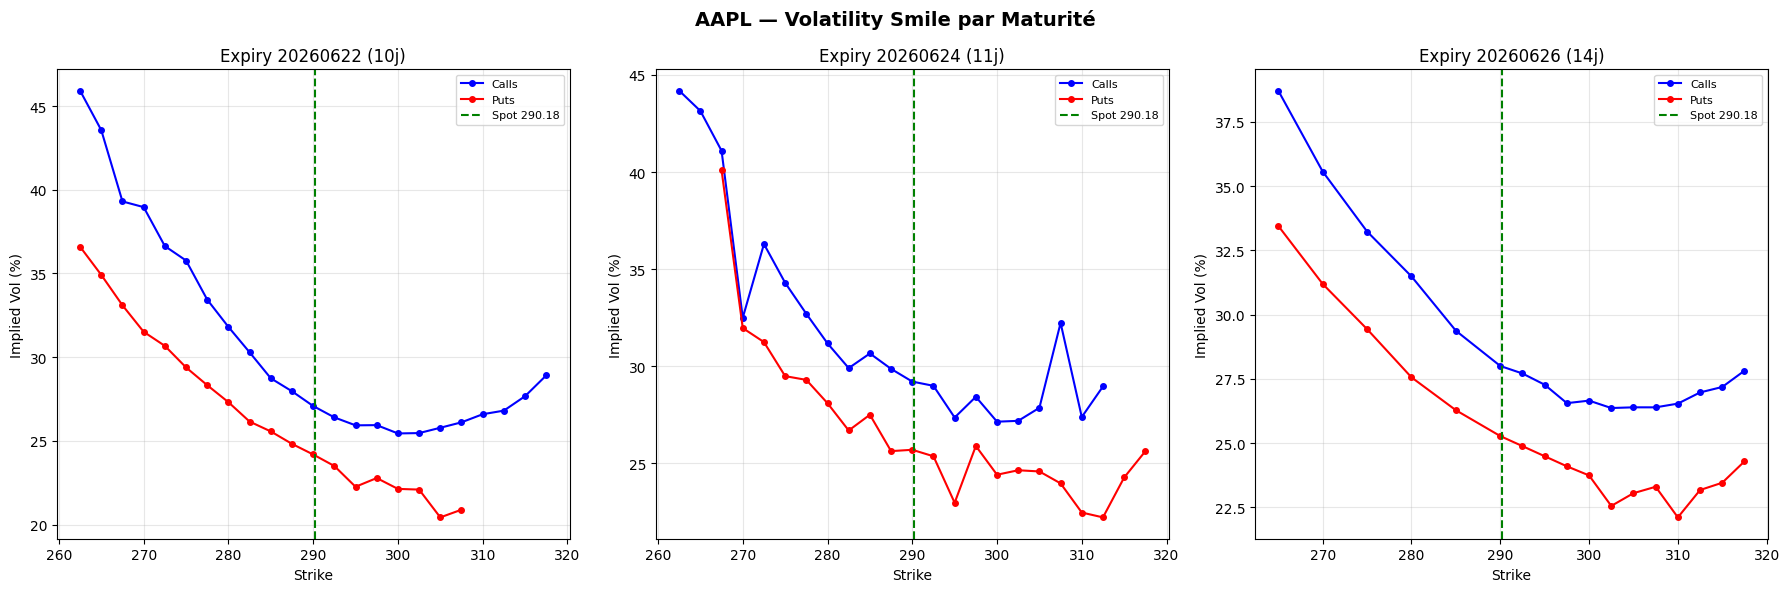

✅ Smile sauvegardé dans data/analytics/


In [6]:
# === STEP 9: Volatility Smile — Visualisation ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, exp in enumerate(sorted(iv_df['expiry'].unique())):
    ax = axes[i]
    exp_data = iv_df[iv_df['expiry'] == exp]
    
    calls = exp_data[exp_data['right'] == 'C']
    puts = exp_data[exp_data['right'] == 'P']
    
    ax.plot(calls['strike'], calls['iv'] * 100, 'bo-', label='Calls', markersize=4)
    ax.plot(puts['strike'], puts['iv'] * 100, 'ro-', label='Puts', markersize=4)
    ax.axvline(x=spot_aapl, color='green', linestyle='--', label=f'Spot {spot_aapl}')
    
    T_days = int(exp_data['T'].values[0] * 365)
    ax.set_title(f'Expiry {exp} ({T_days}j)')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied Vol (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('AAPL — Volatility Smile par Maturité', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/analytics/aapl_vol_smile.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Smile sauvegardé dans data/analytics/")

In [14]:
# # === STEP 10: Pricing Engine — Black-Scholes ===

# def bs_greeks(S, K, T, r, sigma, right='C'):
#     """Prix + Greeks complets (Equations 8-19 du doc)"""
#     if T <= 0 or sigma <= 0:
#         return None
    
#     d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
#     d2 = d1 - sigma*np.sqrt(T)
    
#     # Prix (Eq 10-11)
#     if right == 'C':
#         price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
#         delta = norm.cdf(d1)                          # Eq 13
#     else:
#         price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
#         delta = norm.cdf(d1) - 1                      # Eq 13
    
#     gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))    # Eq 14
#     vega = S * norm.pdf(d1) * np.sqrt(T) / 100         # Eq 15 (per 1 vol point)
#     theta = (-(S * norm.pdf(d1) * sigma) / (2*np.sqrt(T)) 
#              - r*K*np.exp(-r*T)*norm.cdf(d2 if right=='C' else -d2)) / 365  # Eq 16 (per day)
    
#     return {
#         'price': price, 'delta': delta, 'gamma': gamma, 
#         'vega': vega, 'theta': theta, 'd1': d1, 'd2': d2
#     }

# greeks_data = []

# for _, row in iv_df.iterrows():
#     if row['iv'] is None or row['iv'] <= 0:
#         continue
    
#     g = bs_greeks(spot_aapl, row['strike'], row['T'], r, row['iv'], row['right'])
#     if g:
#         greeks_data.append({
#             'expiry': row['expiry'],
#             'strike': row['strike'],
#             'right': row['right'],
#             'iv': row['iv'],
#             'model_price': g['price'],
#             'market_mid': row['mid'],
#             'delta': g['delta'],
#             'gamma': g['gamma'],
#             'vega': g['vega'],
#             'theta': g['theta'],
#         })

# greeks_df = pd.DataFrame(greeks_data)
# print(f"✅ {len(greeks_df)} options pricées avec Greeks")
# print(f"\nExemple — Options ATM (strike 290):")
# print(greeks_df[greeks_df['strike'] == 290.0][['right','iv','model_price','market_mid','delta','gamma','vega','theta']].to_string(index=False))

# === STEP 10 (v2): Pricing Engine — Greeks complets + Dollar Greeks + Rho + RTV ===
# TODO complete:
#  ✅ Dollar Gamma & Dollar Vega (Eq 17-18 du doc)
#  ✅ Rho (sensibilité au taux)
#  ✅ Root Time Vega (vega normalisé par √T)
#  ✅ Start / Mid / End market: IV calculée à partir de bid, mid ET ask

MULTIPLIER = 100  # US equity options


def bs_greeks_full(S, K, T, r, sigma, right='C', multiplier=MULTIPLIER):
    """
    Prix + Greeks complets (Equations 8-19 du doc) + Dollar Greeks + Rho + RTV.

    Returns dict avec:
      - price, delta, gamma, vega, theta (base)
      - dollar_gamma, dollar_vega        (Eq 17-18)
      - rho                              (sensi taux, per 1%)
      - root_time_vega                   (vega/sqrt(T), comparable cross-maturity)
    """
    if T <= 0 or sigma <= 0:
        return None

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Prix + Delta (Eq 10-11, 13)
    if right == 'C':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100      # per 1% rate move
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100    # per 1% rate move

    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))             # Eq 14
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100                  # Eq 15 (per 1 vol point)
    theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
             - r * K * np.exp(-r * T) * norm.cdf(d2 if right == 'C' else -d2)) / 365  # per day

    # === Dollar Greeks (Eq 17-18) ===
    dollar_gamma = gamma * S ** 2 * multiplier                  # PnL pour 1% spot move proportionnel
    dollar_vega = vega * multiplier                             # PnL en $ pour 1 vol point

    # === Root Time Vega — permet de comparer le vega entre maturités ===
    root_time_vega = vega / np.sqrt(T) if T > 0 else None

    return {
        'price': price,
        'delta': delta,
        'gamma': gamma,
        'vega': vega,
        'theta': theta,
        'rho': rho,
        'dollar_gamma': dollar_gamma,
        'dollar_vega': dollar_vega,
        'root_time_vega': root_time_vega,
    }


# === Recalculer les Greeks à partir de iv_df, en ajoutant start/mid/end market ===
# Pour chaque option on calcule l'IV à partir de bid, mid, ask → trois IV possibles
# Ça donne une fourchette de plausibilité (bid-IV = lower bound, ask-IV = upper bound)

greeks_data = []

for _, row in iv_df.iterrows():
    if row['iv'] is None or row['iv'] <= 0:
        continue

    # Retrouver l'option d'origine pour récupérer bid/ask
    opt_row = opts[
        (opts['expiry'] == row['expiry']) &
        (opts['strike'] == row['strike']) &
        (opts['right'] == row['right'])
    ]
    if len(opt_row) == 0:
        continue

    bid_px = opt_row['bid'].iloc[0]
    ask_px = opt_row['ask'].iloc[0]
    mid_px = row['mid']

    # IV à bid, mid, ask (start/mid/end market) — fourchette de plausibilité
    iv_bid = implied_vol(bid_px, spot_aapl, row['strike'], row['T'], r, row['right']) if bid_px and bid_px > 0 else None
    iv_mid = row['iv']  # déjà calculée
    iv_ask = implied_vol(ask_px, spot_aapl, row['strike'], row['T'], r, row['right']) if ask_px and ask_px > 0 else None

    # Greeks calculées à partir de mid IV (référence)
    g = bs_greeks_full(spot_aapl, row['strike'], row['T'], r, iv_mid, row['right'])
    if not g:
        continue

    greeks_data.append({
        'expiry': row['expiry'],
        'strike': row['strike'],
        'right': row['right'],
        'T': row['T'],
        # === Trois prix de marché ===
        'start_market': bid_px,    # start = bid (rentrée côté acheteur)
        'mid_market': mid_px,      # mid = (bid+ask)/2
        'end_market': ask_px,      # end = ask (sortie côté vendeur)
        # === Trois IV correspondantes ===
        'iv_bid': iv_bid,
        'iv_mid': iv_mid,
        'iv_ask': iv_ask,
        'iv_spread': (iv_ask - iv_bid) if (iv_bid and iv_ask) else None,  # largeur de la fourchette IV
        # === Prix modèle & Greeks ===
        'model_price': g['price'],
        'delta': g['delta'],
        'gamma': g['gamma'],
        'vega': g['vega'],
        'theta': g['theta'],
        # === Nouvelles métriques ===
        'rho': g['rho'],
        'dollar_gamma': g['dollar_gamma'],
        'dollar_vega': g['dollar_vega'],
        'root_time_vega': g['root_time_vega'],
    })

greeks_df = pd.DataFrame(greeks_data)

print(f"✅ {len(greeks_df)} options pricées avec Greeks complets\n")

print("=== Exemple ATM (strike 290) — Greeks de base ===")
atm = greeks_df[greeks_df['strike'] == 290.0]
print(atm[['right', 'iv_mid', 'model_price', 'mid_market', 'delta', 'gamma', 'vega', 'theta']].to_string(index=False))

print("\n=== Dollar Greeks + Rho + RTV ===")
print(atm[['right', 'expiry', 'dollar_gamma', 'dollar_vega', 'rho', 'root_time_vega']].to_string(index=False))

print("\n=== Fourchette de marché (start / mid / end) avec IV correspondantes ===")
print(atm[['right', 'start_market', 'mid_market', 'end_market', 'iv_bid', 'iv_mid', 'iv_ask', 'iv_spread']].to_string(index=False))

✅ 118 options pricées avec Greeks complets

=== Exemple ATM (strike 290) — Greeks de base ===
right   iv_mid  model_price  mid_market     delta    gamma     vega     theta
    C 0.270865        5.450       5.450  0.524931 0.030605 0.191241 -0.276306
    P 0.241918        4.375       4.375 -0.474112 0.034261 0.191212 -0.248011
    C 0.292161        6.425       6.425  0.525868 0.025898 0.209463 -0.272207
    P 0.257054        5.100       5.100 -0.473311 0.029431 0.209435 -0.241098
    C 0.280016        6.675       6.675  0.527429 0.025010 0.226187 -0.243444
    P 0.252732        5.400       5.400 -0.471856 0.027706 0.226158 -0.220901

=== Dollar Greeks + Rho + RTV ===
right   expiry  dollar_gamma  dollar_vega       rho  root_time_vega
    C 20260622 257704.153134    19.124142  0.040240        1.155389
    P 20260622 288496.417007    19.121212 -0.038891        1.155212
    C 20260624 218070.444131    20.946308  0.048056        1.155216
    P 20260624 247819.574015    20.943461 -0.046831  

# TO DO

## rajout des greeks en dollars

## rajout du rhor 

## rajout du root time vega

## il veut start, mid et end market pas que market_mid

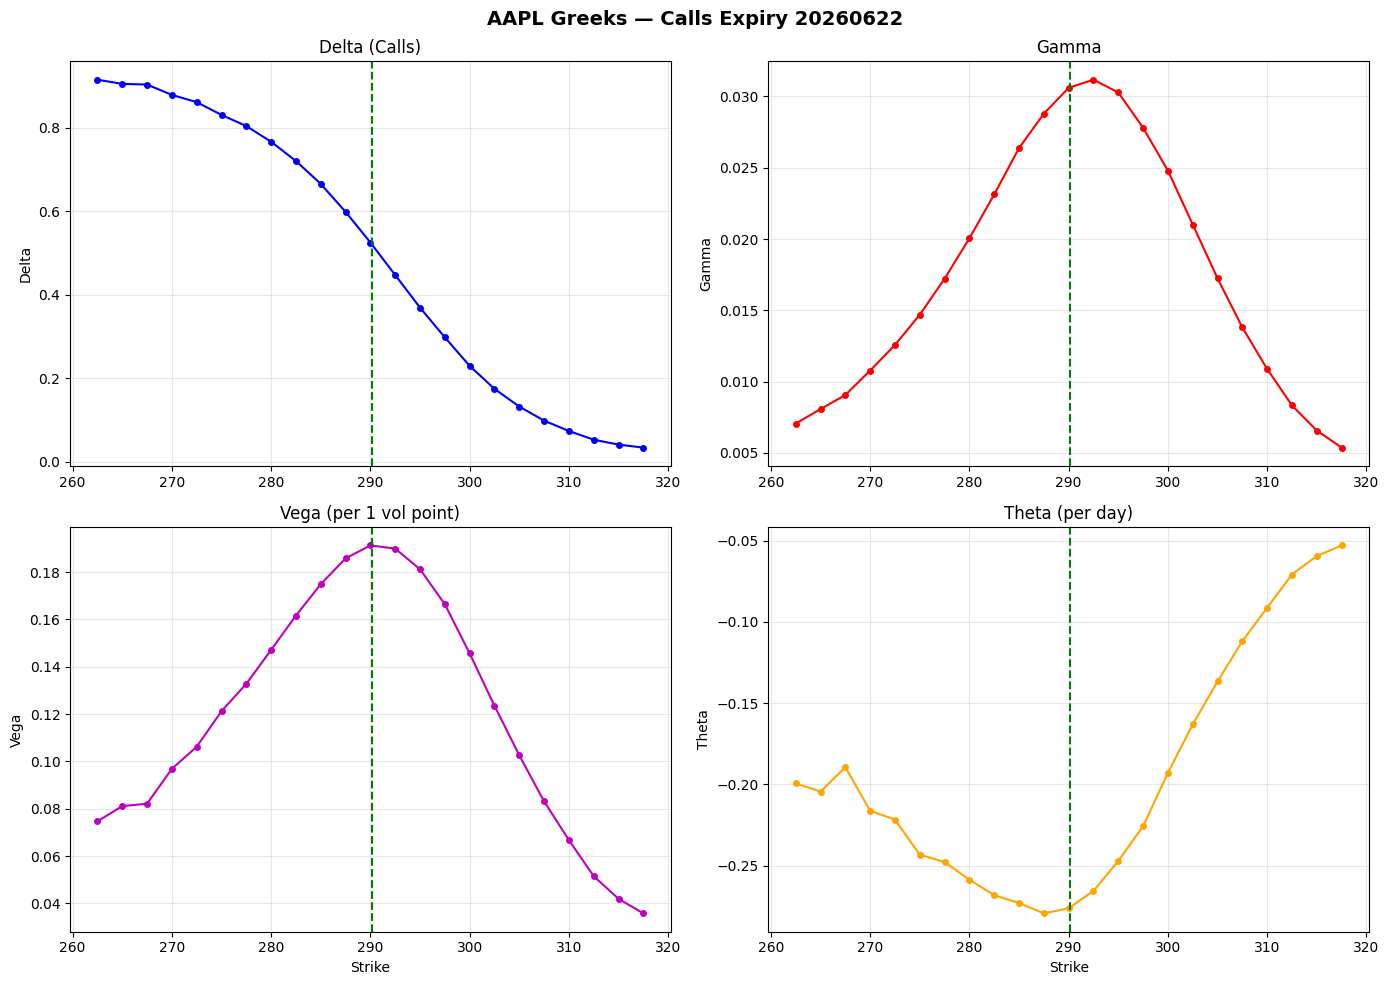

In [15]:
# === STEP 11: Greeks Visualisation ===

exp_focus = sorted(greeks_df['expiry'].unique())[0]  # première expiration
gk = greeks_df[greeks_df['expiry'] == exp_focus]
calls_gk = gk[gk['right'] == 'C']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Delta
axes[0,0].plot(calls_gk['strike'], calls_gk['delta'], 'b-o', markersize=4)
axes[0,0].axvline(spot_aapl, color='green', linestyle='--')
axes[0,0].set_title('Delta (Calls)')
axes[0,0].set_ylabel('Delta')
axes[0,0].grid(True, alpha=0.3)

# Gamma
axes[0,1].plot(calls_gk['strike'], calls_gk['gamma'], 'r-o', markersize=4)
axes[0,1].axvline(spot_aapl, color='green', linestyle='--')
axes[0,1].set_title('Gamma')
axes[0,1].set_ylabel('Gamma')
axes[0,1].grid(True, alpha=0.3)

# Vega
axes[1,0].plot(calls_gk['strike'], calls_gk['vega'], 'm-o', markersize=4)
axes[1,0].axvline(spot_aapl, color='green', linestyle='--')
axes[1,0].set_title('Vega (per 1 vol point)')
axes[1,0].set_ylabel('Vega')
axes[1,0].set_xlabel('Strike')
axes[1,0].grid(True, alpha=0.3)

# Theta
axes[1,1].plot(calls_gk['strike'], calls_gk['theta'], 'orange', marker='o', markersize=4)
axes[1,1].axvline(spot_aapl, color='green', linestyle='--')
axes[1,1].set_title('Theta (per day)')
axes[1,1].set_ylabel('Theta')
axes[1,1].set_xlabel('Strike')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'AAPL Greeks — Calls Expiry {exp_focus}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/analytics/aapl_greeks.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# === STEP 12: Scenario Engine — Stress Test ===

# Ajouter T à greeks_df
T_map = iv_df[['expiry', 'T']].drop_duplicates().set_index('expiry')['T']
greeks_df['T'] = greeks_df['expiry'].map(T_map)

spot_shocks = [-10, -5, -2, 0, 2, 5, 10]
vol_shocks = [-5, -2, 0, 2, 5]

atm_opts = greeks_df[greeks_df['strike'].between(285, 295)].copy()
print(f"Options ATM pour stress test: {len(atm_opts)}")

scenarios = []

for ds in spot_shocks:
    for dv in vol_shocks:
        new_spot = spot_aapl * (1 + ds/100)
        total_pnl_reprice = 0
        total_pnl_greeks = 0
        
        for _, opt in atm_opts.iterrows():
            new_sigma = opt['iv'] + dv/100
            if new_sigma <= 0:
                continue
            
            # Full repricing (méthode exacte)
            new_price = bs_price(new_spot, opt['strike'], opt['T'], r, new_sigma, opt['right'])
            total_pnl_reprice += new_price - opt['model_price']
            
            # Approximation Greeks (Equation 19)
            dS = new_spot - spot_aapl
            total_pnl_greeks += (opt['delta'] * dS 
                                + 0.5 * opt['gamma'] * dS**2 
                                + opt['vega'] * dv 
                                + opt['theta'] * 0)
        
        scenarios.append({
            'spot_shock_%': ds,
            'vol_shock_pts': dv,
            'new_spot': round(new_spot, 2),
            'pnl_reprice': round(total_pnl_reprice, 2),
            'pnl_greeks': round(total_pnl_greeks, 2),
            'approx_error': round(total_pnl_reprice - total_pnl_greeks, 2),
        })

scen_df = pd.DataFrame(scenarios)

pivot = scen_df.pivot(index='spot_shock_%', columns='vol_shock_pts', values='pnl_reprice')
print("\n📊 Matrice de PnL — Full Repricing:")
print(pivot.to_string())

pivot_greeks = scen_df.pivot(index='spot_shock_%', columns='vol_shock_pts', values='pnl_greeks')
print("\n📊 Matrice de PnL — Approximation Greeks:")
print(pivot_greeks.to_string())

pivot_err = scen_df.pivot(index='spot_shock_%', columns='vol_shock_pts', values='approx_error')
print("\n📊 Erreur d'approximation (Reprice - Greeks):")
print(pivot_err.to_string())

Options ATM pour stress test: 28


KeyError: 'iv'

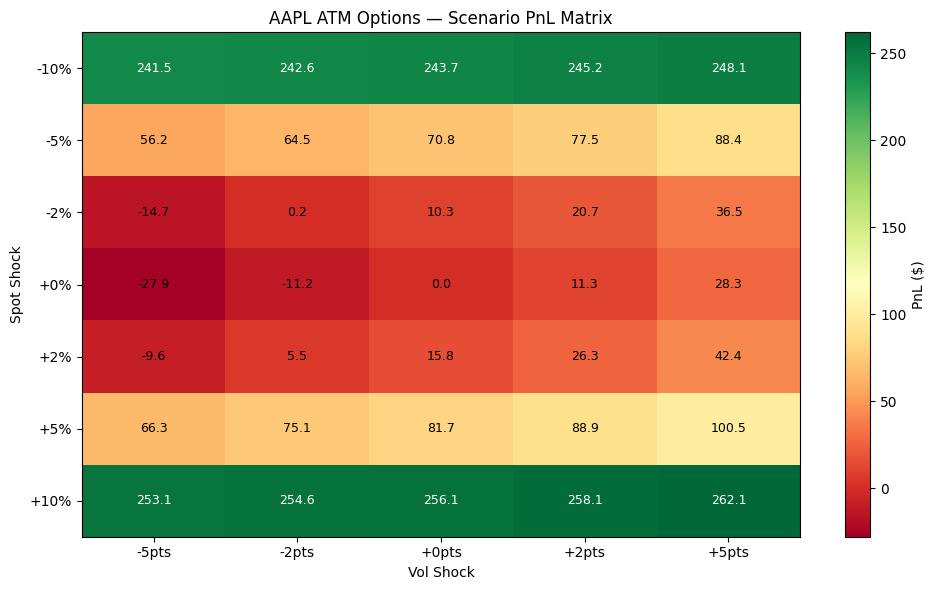

✅ Step 12 validée — Scenario engine opérationnel


In [17]:
# === Heatmap Scénarios ===

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:+d}pts" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{i:+d}%" for i in pivot.index])

ax.set_xlabel('Vol Shock')
ax.set_ylabel('Spot Shock')
ax.set_title('AAPL ATM Options — Scenario PnL Matrix')

# Ajouter les valeurs dans chaque cellule
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = 'white' if abs(val) > pivot.values.max()*0.5 else 'black'
        ax.text(j, i, f"{val:.1f}", ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='PnL ($)')
plt.tight_layout()
plt.savefig('../data/analytics/aapl_scenario_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 12 validée — Scenario engine opérationnel")